# PART 3

Haikal Ali_1103223071_TK46GAB

# Chapter 3 - Statistical Experiments and Significance Testing


In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


## 1. Statistical Experiments and Significance Testing

Desain eksperimen adalah bagian penting dari statistik. Tujuannya adalah merancang eksperimen untuk mengonfirmasi atau menolak sebuah hipotesis. Dalam data science, eksperimen sering digunakan untuk menguji user interface, produk, harga, marketing, dan proses lain yang dapat dibandingkan secara terukur.

Alur inferensi statistik klasik dimulai dari hipotesis, lalu eksperimen dirancang untuk menguji hipotesis tersebut, data dikumpulkan, data dianalisis, dan akhirnya ditarik kesimpulan. Istilah inferensi berarti hasil eksperimen dari data terbatas ingin diterapkan ke proses atau populasi yang lebih besar.


## 2. A/B Testing

A/B test adalah eksperimen dengan dua kelompok untuk menentukan perlakuan, produk, prosedur, harga, headline, atau desain mana yang lebih baik. Salah satu kelompok biasanya menjadi kontrol, yaitu kondisi standar atau tanpa perlakuan baru.

**Istilah penting:**

- **Treatment**: sesuatu yang diberikan kepada subjek, seperti obat, harga, atau headline web.
- **Treatment group**: kelompok subjek yang menerima treatment tertentu.
- **Control group**: kelompok subjek yang tidak menerima treatment baru atau menerima treatment standar.
- **Randomization**: proses membagi subjek ke treatment secara acak.
- **Subjects**: item yang terkena treatment, misalnya pengunjung web atau pasien.
- **Test statistic**: metrik yang digunakan untuk mengukur efek treatment.

Contoh A/B testing meliputi perbandingan dua headline web, dua harga, dua iklan, dua terapi, atau dua perlakuan tanah.


### Tabel 2x2 untuk eksperimen ecommerce

Materi memberi contoh hasil eksperimen harga dengan dua outcome: conversion dan no conversion.


In [2]:

ecommerce_result = pd.DataFrame({
  'Price A': [200, 23539],
  'Price B': [182, 22406]
}, index=['Conversion', 'No conversion'])

ecommerce_result


,Price A,Price B
Conversion,200,182
No conversion,23539,22406


### Mengapa perlu control group?

Control group diperlukan agar perbedaan hasil bisa dibandingkan dengan kondisi yang sama, kecuali treatment yang diuji. Jika hanya membandingkan treatment baru dengan pengalaman sebelumnya atau baseline lama, faktor lain di luar treatment bisa ikut berubah dan membuat kesimpulan menjadi bias.

### Blinding

Blind study adalah studi ketika subjek tidak tahu apakah mereka menerima treatment A atau B. Double-blind study berarti subjek, peneliti, dan fasilitator juga tidak tahu siapa menerima treatment mana. Blinding tidak selalu bisa dilakukan, terutama jika bentuk treatment sangat jelas.

### A/B/C/D dan multi-arm bandit

A/B test tidak terbatas pada dua kelompok. Treatment tambahan seperti C, D, dan seterusnya dapat digunakan. Namun, data scientist sering lebih tertarik pada pertanyaan “pilihan mana yang terbaik?” daripada sekadar “apakah perbedaan A dan B signifikan?”. Untuk konteks seperti ini, materi memperkenalkan multi-arm bandit.

**Gagasan utama:** subjek dibagi ke dua atau lebih kelompok yang diperlakukan sama, kecuali treatment yang sedang diuji. Idealnya, pembagian subjek dilakukan secara acak.


## 3. Hypothesis Tests

Hypothesis test atau significance test digunakan untuk menilai apakah random chance dapat menjelaskan efek yang terlihat pada data.

**Istilah penting:**

- **Null hypothesis**: hipotesis bahwa perbedaan yang terlihat disebabkan oleh chance.
- **Alternative hypothesis**: hipotesis tandingan yang ingin dibuktikan.
- **One-way test**: hanya menghitung hasil ekstrem pada satu arah.
- **Two-way test**: menghitung hasil ekstrem pada dua arah.

Dalam A/B test, perbedaan antara group A dan group B dapat terjadi karena dua hal: random chance dalam pembagian subjek, atau memang ada perbedaan nyata antara A dan B.


### Null hypothesis

Null hypothesis adalah asumsi awal bahwa treatment setara dan perbedaan yang terlihat hanya terjadi karena chance. Untuk menguji ini, hasil dari group A dan B dapat digabung, diacak ulang, lalu dibagi ulang menjadi kelompok dengan ukuran yang sama. Prosedur ini membentuk null model.

### Alternative hypothesis

Contoh pasangan null dan alternative hypothesis:

- Null: tidak ada perbedaan mean antara A dan B; alternative: A berbeda dari B.
- Null: A <= B; alternative: A > B.
- Null: B tidak X% lebih besar dari A; alternative: B X% lebih besar dari A.

### One-way vs two-way

One-way test digunakan jika hanya satu arah yang penting, misalnya B harus terbukti lebih baik dari A. Two-way test digunakan jika perbedaan pada dua arah sama-sama penting, misalnya A berbeda dari B, baik lebih tinggi maupun lebih rendah.

**Gagasan utama:** hypothesis test mengasumsikan null hypothesis benar, membuat null model, lalu mengecek apakah efek yang diamati masih masuk akal sebagai hasil dari chance.


## 4. Resampling

Resampling berarti mengambil sampel berulang dari data yang diamati untuk menilai variasi acak dari suatu statistik. Dua bentuk utama resampling adalah bootstrap dan permutation test. Bootstrap digunakan untuk menilai reliabilitas estimasi, sedangkan permutation test digunakan untuk menguji hipotesis.

**Istilah penting:**

- **Permutation test**: menggabungkan dua atau lebih sampel, lalu mengacak ulang observasi ke dalam resample.
- **Resampling**: mengambil sampel tambahan dari data yang diamati.
- **With or without replacement**: apakah item dikembalikan ke sampel sebelum pengambilan berikutnya.


### Permutation Test

Langkah umum permutation test:

1. Gabungkan hasil dari kelompok yang berbeda ke satu data set.
2. Acak data gabungan, lalu ambil resample sebesar group A tanpa replacement.
3. Dari sisa data, ambil resample sebesar group B tanpa replacement.
4. Lakukan hal yang sama untuk group C, D, dan seterusnya jika ada.
5. Hitung statistik yang sama seperti pada data asli.
6. Ulangi proses berkali-kali untuk membentuk permutation distribution.

Observed statistic kemudian dibandingkan dengan distribusi hasil permutasi. Jika observed statistic berada jauh di luar sebagian besar hasil permutasi, maka chance kurang masuk akal sebagai penjelasan.


### Example: Web Stickiness

Materi menggunakan contoh dua halaman web, Page A dan Page B. Metrik yang digunakan adalah average session time. Page B memiliki rata-rata session time lebih tinggi daripada Page A sebesar 35.67 detik. Pertanyaannya adalah apakah selisih ini masih mungkin terjadi karena chance.

Data mentah `session_times` tidak dicantumkan lengkap di PDF. Struktur yang digunakan oleh kode adalah DataFrame dengan kolom `Page` dan `Time`.


In [3]:

def perm_fun(x, nA, nB):
  n = nA + nB
  idx_B = set(random.sample(range(n), nB))
  idx_A = set(range(n)) - idx_B
  return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()


In [4]:

if 'session_times' in globals():
  ax = session_times.boxplot(by='Page', column='Time')
  ax.set_xlabel('')
  ax.set_ylabel('Time (in seconds)')
  plt.suptitle('')
else:
  print('Data session_times tidak dicantumkan lengkap di PDF.')


Data session_times tidak dicantumkan lengkap di PDF.


In [5]:

if 'session_times' in globals():
  mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
  mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
  mean_b - mean_a
else:
  print('Data session_times tidak dicantumkan lengkap di PDF.')


Data session_times tidak dicantumkan lengkap di PDF.


In [6]:

if 'session_times' in globals():
  nA = 21
  nB = 15
  perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

  fig, ax = plt.subplots(figsize=(5, 5))
  ax.hist(perm_diffs, bins=11, rwidth=0.9)
  ax.axvline(x=mean_b - mean_a, color='black', lw=2)
  ax.text(50, 190, 'Observed\\ndifference', bbox={'facecolor':'white'})
  ax.set_xlabel('Session time differences (in seconds)')
  ax.set_ylabel('Frequency')
else:
  print('Data session_times tidak dicantumkan lengkap di PDF.')


Data session_times tidak dicantumkan lengkap di PDF.


In [7]:

if 'session_times' in globals():
  np.mean(perm_diffs > mean_b - mean_a)
else:
  print('Data session_times tidak dicantumkan lengkap di PDF.')


Data session_times tidak dicantumkan lengkap di PDF.


Materi menyatakan bahwa hasil simulasi menunjukkan perbedaan rata-rata random permutation sering melebihi observed difference. Dengan hasil sekitar 12.1% sampai 12.6%, selisih session time Page A dan Page B masih berada dalam rentang variasi chance dan tidak signifikan secara statistik.


### Exhaustive dan Bootstrap Permutation Tests

Selain random permutation test, ada dua varian lain:

- **Exhaustive permutation test**: menghitung semua cara pembagian data. Praktis hanya untuk ukuran sampel kecil.
- **Bootstrap permutation test**: pengambilan dilakukan dengan replacement, sehingga memodelkan unsur acak dalam penugasan treatment dan pemilihan subjek dari populasi.

**Gagasan utama:** permutation test menggabungkan beberapa sampel, mengacak nilai, membagi ulang ke resample, menghitung statistik, lalu membandingkan observed statistic dengan distribusi hasil resampling.


## 5. Statistical Significance and p-Values

Statistical significance digunakan untuk menilai apakah hasil eksperimen lebih ekstrem daripada yang mungkin dihasilkan oleh chance. Jika hasil berada di luar rentang variasi chance, hasil disebut statistically significant.

**Istilah penting:**

- **p-value**: probabilitas mendapatkan hasil yang sama ekstrem atau lebih ekstrem dari hasil observasi, dengan asumsi null model benar.
- **Alpha**: ambang probabilitas untuk menentukan apakah hasil cukup tidak biasa untuk dianggap signifikan.
- **Type 1 error**: salah menyimpulkan efek nyata padahal sebenarnya karena chance.
- **Type 2 error**: salah menyimpulkan efek karena chance padahal sebenarnya nyata.


### Contoh conversion rate harga A dan B

Price A memiliki conversion rate 0.8425%, sedangkan Price B 0.8057%. Selisihnya 0.0368 percentage points. Walaupun total data lebih dari 45.000, jumlah conversion hanya ratusan, sehingga pengujian chance tetap relevan.


Observed difference: 0.0368%


Text(0, 0.5, 'Frequency')

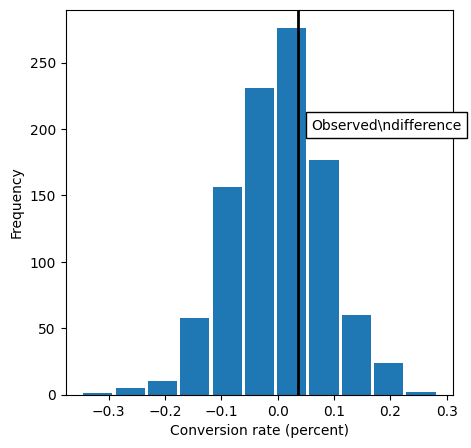

In [8]:

obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')

conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588)
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')


In [9]:

np.mean([diff > obs_pct_diff for diff in perm_diffs])


np.float64(0.329)

Materi memberi nilai p-value sekitar 0.308. Artinya, dengan null model, hasil seekstrem observed result atau lebih ekstrem dapat terjadi karena chance lebih dari 30% dari waktu. Jadi hasil ini masih berada dalam rentang chance variation.


In [10]:

survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test: {p_value / 2:.4f}')


p-value for single sided test: 0.3498


### Alpha

Alpha adalah ambang yang ditentukan sebelum analisis, misalnya 5% atau 1%. Alpha bukan probabilitas bahwa keputusan pasti benar. Alpha menjawab pertanyaan: dengan chance model, seberapa mungkin hasil seekstrem ini muncul?

### Kontroversi p-value

Materi menekankan bahwa p-value sering disalahartikan. p-value bukan probabilitas bahwa hipotesis benar atau bahwa hasil terjadi karena chance saja. p-value menunjukkan probabilitas mendapatkan data seekstrem hasil observasi dengan asumsi model statistik tertentu.

Enam prinsip ASA yang disebutkan materi:

1. P-value dapat menunjukkan seberapa tidak kompatibel data dengan model statistik tertentu.
2. P-value tidak mengukur probabilitas bahwa hipotesis yang dipelajari benar atau bahwa data dihasilkan oleh chance saja.
3. Keputusan ilmiah, bisnis, atau kebijakan tidak boleh hanya berdasarkan ambang p-value.
4. Inferensi yang baik membutuhkan pelaporan lengkap dan transparansi.
5. P-value atau statistical significance tidak mengukur ukuran efek atau pentingnya hasil.
6. P-value saja bukan ukuran bukti yang baik untuk model atau hipotesis.

### Practical significance

Hasil yang statistically significant belum tentu penting secara praktis. Sampel sangat besar bisa membuat efek kecil dan tidak bermakna menjadi signifikan secara statistik.

### Type 1 dan Type 2 Errors

- **Type 1 error**: menyimpulkan efek nyata padahal hanya karena chance.
- **Type 2 error**: menyimpulkan efek tidak nyata padahal efek sebenarnya ada.

Dalam data science, p-value berguna sebagai salah satu informasi untuk mengecek apakah hasil yang tampak menarik masih berada dalam rentang chance variation, tetapi tidak seharusnya menjadi satu-satunya dasar keputusan.


## 6. t-Tests

T-test adalah salah satu significance test yang umum digunakan untuk membandingkan mean. T-test menggunakan Student's t-distribution sebagai reference distribution. Dalam resampling test, skala data tidak terlalu menjadi masalah karena reference distribution dibuat dari data itu sendiri. Pada pendekatan formula klasik, test statistic perlu distandardisasi agar dapat dibandingkan dengan t-distribution.

**Istilah penting:**

- **Test statistic**: metrik untuk perbedaan atau efek yang diamati.
- **t-statistic**: versi terstandarisasi dari statistik seperti mean.
- **t-distribution**: reference distribution untuk membandingkan observed t-statistic.


In [11]:

if 'session_times' in globals():
  res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                        session_times[session_times.Page == 'Page B'].Time,
                        equal_var=False)
  print(f'p-value for single sided test: {res.pvalue / 2:.4f}')
else:
  print('Data session_times tidak dicantumkan lengkap di PDF.')


Data session_times tidak dicantumkan lengkap di PDF.


Materi menyatakan bahwa p-value t-test satu sisi untuk contoh session time adalah 0.1408, cukup dekat dengan hasil permutation test sekitar 0.121 dan 0.126.

**Gagasan utama:** sebelum komputer umum digunakan, resampling tidak praktis, sehingga statistik klasik menggunakan reference distribution. Salah satu statistik terstandarisasi yang umum digunakan adalah t-statistic.


## 7. Multiple Testing

Multiple testing terjadi ketika data diuji dari banyak sudut, banyak variabel, atau banyak model. Semakin banyak pengujian dilakukan, semakin besar peluang menemukan hasil yang tampak signifikan hanya karena chance.

Contoh dari materi: jika ada 20 predictor dan 1 outcome yang semuanya random, lalu dilakukan 20 significance tests dengan alpha = 0.05, peluang setidaknya satu predictor salah terlihat signifikan adalah 1 - 0.95^20 = 0.64. Ini disebut **alpha inflation**.

**Istilah penting:**

- **Type 1 error**: salah menyimpulkan efek signifikan.
- **False discovery rate**: tingkat Type 1 error pada banyak pengujian.
- **Alpha inflation**: kenaikan probabilitas Type 1 error ketika banyak tes dilakukan.
- **Adjustment of p-values**: penyesuaian p-value karena melakukan banyak tes pada data yang sama.
- **Overfitting**: fitting terhadap noise.

Dalam predictive modeling, risiko ini dapat dikurangi dengan cross-validation dan holdout sample. Pada analisis tanpa labeled holdout set, perlu kesadaran bahwa semakin sering data dimanipulasi dan ditanya, semakin besar peran chance.


## 8. Degrees of Freedom

Degrees of freedom adalah jumlah nilai yang bebas bervariasi dalam statistik yang dihitung dari sampel. Jika diketahui mean dari 10 nilai, maka hanya 9 nilai yang bebas; nilai ke-10 dapat dihitung dari mean dan 9 nilai lainnya.

Dalam variance dan standard deviation, denominator n - 1 digunakan untuk mengurangi bias saat sampel digunakan untuk memperkirakan varians populasi.

Dalam data science, konsep ini tidak terlalu penting untuk significance testing karena formal statistical test lebih jarang digunakan, dan ukuran data sering cukup besar sehingga perbedaan antara n dan n - 1 kecil. Namun, degrees of freedom relevan saat categorical variable diubah menjadi dummy variables. Untuk kategori dengan n level, hanya n - 1 dummy variables yang digunakan untuk menghindari multicollinearity.

**Gagasan utama:** degrees of freedom membantu standardisasi test statistic terhadap reference distribution dan menjelaskan mengapa categorical variable biasanya difaktorkan menjadi n - 1 dummy variables dalam regression.


## 9. ANOVA

ANOVA atau analysis of variance digunakan ketika terdapat lebih dari dua kelompok numerik, misalnya A/B/C/D test. ANOVA menguji apakah variasi antar group means masih masuk akal sebagai chance variation.

**Istilah penting:**

- **Pairwise comparison**: uji hipotesis antara dua kelompok dari beberapa kelompok.
- **Omnibus test**: satu uji keseluruhan untuk variasi antar group means.
- **Decomposition of variance**: pemisahan komponen nilai menjadi grand average, treatment mean, dan residual error.
- **F-statistic**: statistik terstandarisasi untuk mengukur apakah perbedaan group means melebihi yang diharapkan dari chance.
- **SS**: sum of squares.


### Data stickiness empat halaman web

Tabel berikut berasal dari materi, berisi waktu yang dihabiskan visitor pada empat halaman web.


In [12]:

four_sessions = pd.DataFrame({
  'Page': ['Page 1'] * 5 + ['Page 2'] * 5 + ['Page 3'] * 5 + ['Page 4'] * 5,
  'Time': [164, 172, 177, 156, 195,
           178, 191, 182, 185, 177,
           175, 193, 171, 163, 176,
           155, 166, 164, 170, 168]
})

four_sessions.head()


,Page,Time
0,Page 1,164
1,Page 1,172
2,Page 1,177
3,Page 1,156
4,Page 1,195


In [13]:

observed_variance = four_sessions.groupby('Page')['Time'].mean().var()
print('Observed means:', four_sessions.groupby('Page')['Time'].mean().values.ravel())
print('Variance:', observed_variance)

def perm_test(df):
  df = df.copy()
  df['Time'] = np.random.permutation(df['Time'].values)
  return df.groupby('Page')['Time'].mean().var()

perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))


Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
Pr(Prob) 0.073


Materi memberi p-value permutation ANOVA sebesar 0.09278. Artinya, jika semua halaman memiliki stickiness yang sama, sekitar 9.3% waktu variasi group means bisa sebesar observed result hanya karena chance. Nilai ini belum melewati threshold 5%.


### F-Statistic

F-statistic adalah rasio antara variasi antar group means atau treatment effect terhadap variasi residual error. Semakin tinggi rasio ini, semakin kuat indikasi perbedaan antar kelompok.


In [14]:

model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
aov_table


,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


### Decomposition of Variance

Setiap nilai observasi dapat dipecah menjadi:

1. Grand average.
2. Treatment effect.
3. Residual error.

Pada contoh nilai kiri atas 164:

1. Grand average = 173.75.
2. Treatment effect = -1.75, yaitu 172 - 173.75.
3. Residual = -8, yaitu 164 - 172.
4. Total = 164.

### Two-Way ANOVA

One-way ANOVA memiliki satu faktor yang berubah, misalnya halaman web. Two-way ANOVA memiliki faktor kedua, misalnya weekend versus weekday. Pada kasus ini, perlu memperhitungkan interaction effect.

**Gagasan utama:** ANOVA adalah perluasan dari A/B test untuk banyak kelompok, digunakan untuk menilai apakah variasi antar kelompok masih berada dalam rentang chance variation.


## 10. Chi-Square Test

Chi-square test digunakan pada count data untuk menguji seberapa jauh data observasi menyimpang dari distribusi yang diharapkan. Penggunaan umum adalah pada contingency table r x c untuk menilai apakah null hypothesis of independence masih masuk akal.

**Istilah penting:**

- **Chi-square statistic**: ukuran seberapa jauh observed data menyimpang dari expected data.
- **Expected**: hasil yang diharapkan dengan asumsi tertentu, biasanya null hypothesis.
- **r x c**: tabel dengan r baris dan c kolom.


### Chi-square test dengan resampling

Materi memberi contoh tiga headline A, B, dan C, masing-masing ditampilkan ke 1.000 visitor.


In [15]:

clicks = pd.DataFrame({
  'Headline A': [14, 986],
  'Headline B': [8, 992],
  'Headline C': [12, 988]
}, index=['Click', 'No-click'])

clicks


,Headline A,Headline B,Headline C
Click,14,8,12
No-click,986,992,988


Jika semua headline memiliki click rate yang sama, expected clicks adalah 34/3 = 11.33 untuk setiap headline, dan expected no-clicks adalah 988.67.

Pearson residual didefinisikan sebagai:

R = (Observed - Expected) / sqrt(Expected)

Chi-square statistic adalah jumlah squared Pearson residuals.


In [16]:

box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
  pearson_residuals = []
  for row, expect in zip(observed, expected):
    pearson_residuals.append([(observe - expect) ** 2 / expect
                              for observe in row])
  return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [34 / 3, 1000 - 34 / 3]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
  sample_clicks = [sum(random.sample(box, 1000)),
                   sum(random.sample(box, 1000)),
                   sum(random.sample(box, 1000))]
  sample_noclicks = [1000 - n for n in sample_clicks]
  return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = pd.Series([perm_fun(box) for _ in range(2000)])
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')


Observed chi2: 1.6659
Resampled p-value: 0.4830


Materi memberi nilai resampled p-value sekitar 0.4853. Hasil ini menunjukkan perbedaan click antar headline masih mudah terjadi karena randomness.


### Chi-square test berdasarkan statistical theory

Untuk contingency table, degrees of freedom dihitung sebagai:

(r - 1) x (c - 1)

Semakin jauh observed statistic di ekor distribusi chi-square, semakin rendah p-value.


In [17]:

chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'p-value: {pvalue:.4f}')


Observed chi2: 1.6659
p-value: 0.4348


### Fisher's Exact Test

Fisher's exact test digunakan ketika count sangat rendah, terutama lima atau kurang. Materi menyatakan bahwa tidak ada implementasi Fisher's exact test yang mudah tersedia di Python untuk kasus ini.

### Detecting Scientific Fraud

Materi memberi contoh kasus Thereza Imanishi-Kari. Investigasi melihat frekuensi digit interior dalam data laboratorium. Jika digit acak, setiap digit diharapkan muncul sekitar 31.5 kali dari total 315 digit. Distribusi aktual terlihat tidak random.

| Digit | Frequency |
|---:|---:|
| 0 | 14 |
| 1 | 71 |
| 2 | 7 |
| 3 | 65 |
| 4 | 23 |
| 5 | 19 |
| 6 | 12 |
| 7 | 45 |
| 8 | 53 |
| 9 | 6 |

### Relevance for Data Science

Dalam data science, chi-square test dan Fisher's exact test lebih sering digunakan sebagai filter untuk menentukan apakah efek atau fitur layak dipertimbangkan lebih lanjut, bukan sebagai formal test of significance untuk publikasi.

**Gagasan utama:** chi-square test menguji apakah observed count konsisten dengan asumsi independence. Chi-square distribution menjadi reference distribution untuk membandingkan observed chi-square statistic.


## 11. Multi-Arm Bandit Algorithm

Multi-arm bandit adalah pendekatan eksperimen, terutama web testing, yang memungkinkan optimasi eksplisit dan keputusan lebih cepat daripada desain statistik tradisional.

**Istilah penting:**

- **Multi-arm bandit**: analogi slot machine dengan banyak lengan, setiap lengan memiliki payoff berbeda.
- **Arm**: treatment dalam eksperimen.
- **Win**: hasil sukses eksperimen, misalnya customer click.

Pada A/B test tradisional, eksperimen dirancang untuk menjawab pertanyaan spesifik seperti “A atau B lebih baik?”. Multi-arm bandit lebih fleksibel karena informasi yang masuk selama eksperimen dapat langsung mengubah probabilitas pemilihan treatment.


### Contoh tiga arm

Materi memberi hasil awal:

- Arm A: 10 wins dari 50.
- Arm B: 2 wins dari 50.
- Arm C: 4 wins dari 50.

Pendekatan ekstrem pertama adalah langsung memilih Arm A. Masalahnya, B atau C mungkin sebenarnya lebih baik tetapi belum terlihat karena chance. Pendekatan ekstrem kedua adalah terus membagi rata semua arm. Masalahnya, treatment yang tampak inferior tetap mendapat exposure terlalu banyak.

Bandit algorithm mengambil pendekatan campuran: arm yang tampak lebih baik ditarik lebih sering, tetapi arm lain tidak langsung ditinggalkan.


### Epsilon-greedy algorithm

Algoritma sederhana epsilon-greedy untuk A/B test:

1. Buat angka random uniform antara 0 dan 1.
2. Jika angka berada antara 0 dan epsilon, lakukan pemilihan acak 50/50:
   - Jika heads, tampilkan offer A.
   - Jika tails, tampilkan offer B.
3. Jika angka >= epsilon, tampilkan offer dengan response rate tertinggi sampai saat itu.

Jika epsilon = 1, algoritma menjadi A/B test random biasa. Jika epsilon = 0, algoritma menjadi greedy dan langsung memilih pilihan terbaik saat ini tanpa eksperimen lanjut.

### Thompson's sampling

Thompson's sampling menggunakan pendekatan Bayesian. Reward awal diasumsikan memiliki prior distribution, lalu informasi baru dari setiap draw memperbarui pemilihan draw berikutnya.

**Gagasan utama:** multi-arm bandit mengubah proses sampling berdasarkan informasi selama eksperimen, mengurangi exposure ke treatment inferior, dan lebih efisien untuk lebih dari dua treatment.


## 12. Power and Sample Size

Power dan sample size digunakan untuk memperkirakan berapa banyak data yang dibutuhkan agar suatu efek bisa terdeteksi dalam hypothesis test.

**Istilah penting:**

- **Effect size**: ukuran minimum efek yang ingin dideteksi, misalnya peningkatan click rate 20%.
- **Power**: probabilitas mendeteksi effect size tertentu dengan sample size tertentu.
- **Significance level**: tingkat signifikansi statistik yang digunakan.

Semakin kecil efek yang ingin dideteksi, semakin besar data yang dibutuhkan. Untuk membedakan perbedaan besar, sample size lebih kecil bisa cukup. Untuk membedakan perbedaan kecil, sample size perlu jauh lebih besar.


### Pendekatan intuitif untuk power

Langkah dari materi:

1. Mulai dari data hipotetis yang mewakili tebakan terbaik tentang data yang akan muncul.
2. Buat sampel kedua dengan menambahkan desired effect size.
3. Ambil bootstrap sample berukuran n dari tiap box.
4. Jalankan permutation atau formula-based hypothesis test.
5. Ulangi berkali-kali dan hitung seberapa sering hasil signifikan. Itulah estimated power.


### Sample size

Contoh materi: current click-through rate sekitar 1.1%, dan target peningkatan 10% menjadi 1.21%. Dengan power 80% dan alpha 0.05, sample size yang dibutuhkan hampir 120.000 impressions.


In [18]:

effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)


Sample Size: 116602.391


Materi menyatakan bahwa jika target peningkatan menjadi 50% (p1 = 0.0165), sample size turun menjadi sekitar 5.500 impressions.

**Gagasan utama:** untuk menghitung sample size, perlu menentukan effect size minimum, power yang diinginkan, dan alpha. Sample size bergantung kuat pada ukuran efek yang ingin dideteksi.


## 13. Summary

Prinsip experimental design adalah randomization subjek ke dua atau lebih group yang menerima treatment berbeda. Control treatment berupa “tidak melakukan perubahan” sebaiknya disertakan. Formal statistical inference seperti hypothesis testing, p-values, t-tests, dan prosedur sejenis banyak dibahas dalam statistik tradisional, tetapi formalitasnya tidak selalu dibutuhkan dalam data science. Yang tetap penting adalah memahami bahwa random variation dapat menipu interpretasi. Prosedur resampling seperti permutation dan bootstrap membantu data scientist mengukur seberapa besar chance variation dapat memengaruhi analisis.

